# 03 — Exploratory Data Analysis

Structured by business question, not by chart type. Every chart has a written
takeaway underneath it — a chart without an interpretation answers nothing.

Loads the feature tables saved by notebook 02. No cleaning or feature
engineering is repeated here.

## Business questions

1. **Revenue health** — how is monthly revenue trending, and is growth driven by
   new or returning customers?
2. **Concentration risk** — which products and countries drive revenue? Does 80/20 hold?
3. **Retention** — what share of customers buy twice, and how fast does each cohort decay?
4. **Customer value** — who is high-value, loyal, at risk, and how much revenue is at risk?
5. **Leakage** — how much revenue is lost to cancellations?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
df = pd.read_parquet("../data/processed/retail_features.parquet")
orders = pd.read_parquet("../data/processed/orders.parquet")
customers = pd.read_parquet("../data/processed/customers.parquet")
cohorts = pd.read_parquet("../data/processed/cohorts.parquet")

sales = df[~df["is_cancelled"]]

df.shape, orders.shape, customers.shape, cohorts.shape

((1021128, 15), (39516, 7), (5852, 8), (36594, 11))

In [3]:
df["InvoiceDate"].min(), df["InvoiceDate"].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2011-12-09 12:50:00'))

## Q1a - How is monthly revenue trending?

Revenue by calendar month, cancellations excluded.

**December 2011 is excluded from the chart.** The data stops on 9 December, so
that month covers 9 days rather than 31. Plotting it would show a 58% revenue
collapse that did not happen. 24 complete months remain.

In [4]:
monthly = sales.groupby("year_month")["Revenue"].sum()
monthly_full = monthly[monthly.index != "2011-12"]

monthly_full.round(2)

year_month
2009-12     797738.02
2010-01     612271.20
2010-02     537893.54
2010-03     761665.62
2010-04     646233.18
2010-05     643474.28
2010-06     696439.47
2010-07     632983.51
2010-08     674036.87
2010-09     869224.44
2010-10    1094357.68
2010-11    1429553.47
2010-12     775572.23
2011-01     670361.99
2011-02     507783.42
2011-03     689708.49
2011-04     515354.78
2011-05     739914.35
2011-06     737558.98
2011-07     688144.79
2011-08     724196.76
2011-09    1028313.80
2011-10    1103310.96
2011-11    1452112.69
Name: Revenue, dtype: float64

In [5]:
monthly_full.idxmax(), monthly_full.max(), monthly_full.idxmin(), monthly_full.min()

('2011-11', 1452112.69, '2011-02', 507783.42)

In [6]:
year_1 = monthly["2009-12":"2010-11"].sum()
year_2 = monthly["2010-12":"2011-11"].sum()

year_1.round(2), year_2.round(2), round(100 * (year_2 - year_1) / year_1, 1)

(np.float64(9395871.28), np.float64(9632333.24), np.float64(2.5))

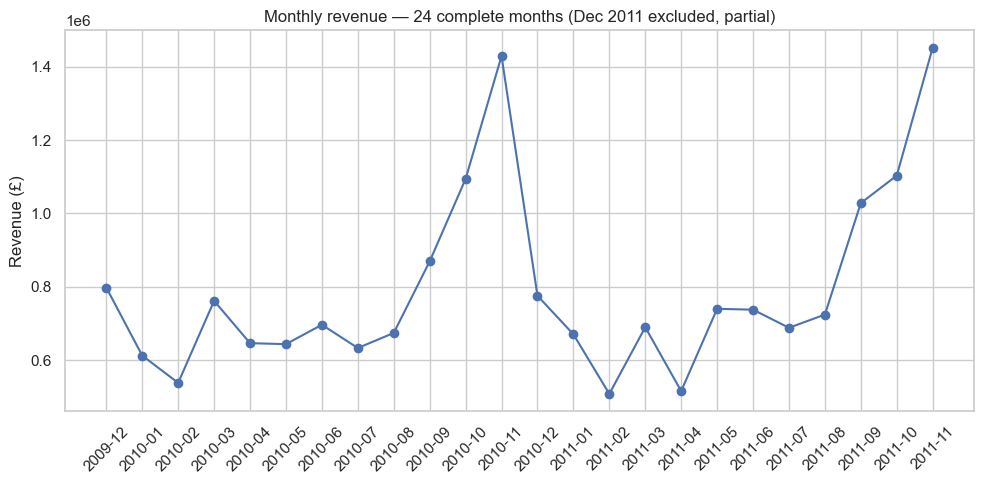

In [7]:
monthly_full.plot(kind="line", marker="o")

plt.title("Monthly revenue — 24 complete months (Dec 2011 excluded, partial)")
plt.ylabel("Revenue (£)")
plt.xlabel("")
plt.xticks(range(len(monthly_full)), monthly_full.index, rotation=45)
plt.tight_layout()
plt.show()

## Q1b — Is revenue driven by new or returning customers?

Each order is tagged from the cohort table: an order at `cohort_index == 0` is
that customer's first-ever purchase (**new**); any later order is **returning**.

This split covers identified customers only (the £17.07M cohort table), since a
customer with no ID can't be placed as new or returning. December 2011 is again
excluded as a partial month.

In [8]:
cohorts["customer_type"] = cohorts["cohort_index"].apply(
    lambda x: "New" if x == 0 else "Returning"
)

split = cohorts[cohorts["order_month"] != "2011-12"].pivot_table(
    index="order_month",
    columns="customer_type",
    values="order_value",
    aggfunc="sum",
).fillna(0)

split.round(2).head()

customer_type,New,Returning
order_month,,
2009-12,677916.07,0.00
2010-01,157879.40,375833.58
2010-02,166559.47,331378.10
2010-03,208717.31,457256.36
2010-04,122829.49,462297.94


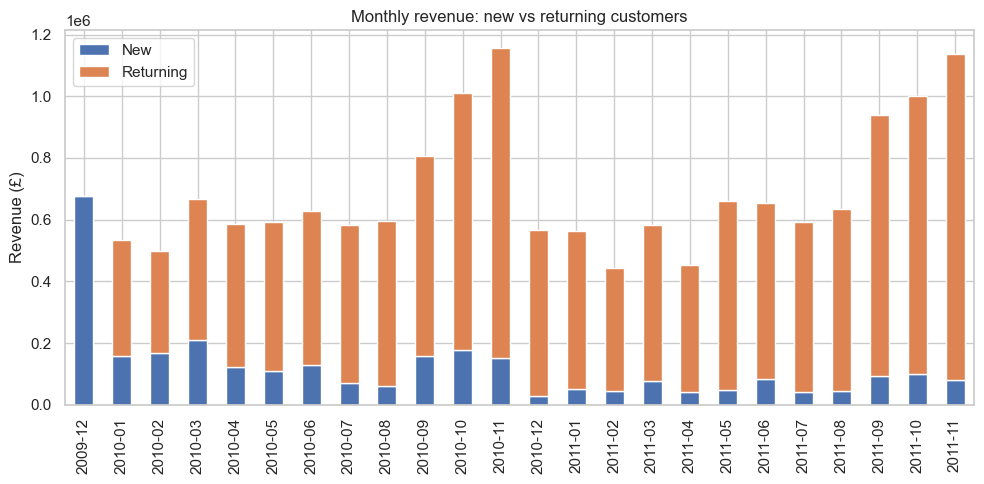

In [9]:
split.plot(kind="bar", stacked=True, color=["#4C72B0", "#DD8452"])

plt.title("Monthly revenue: new vs returning customers")
plt.ylabel("Revenue (£)")
plt.xlabel("")
plt.legend(title="")
plt.tight_layout()
plt.show()

**Takeaway.** Returning customers generate **82.8% of identified revenue**
(£14.13M of £17.07M); new customers only 17%. New-customer revenue declines
over the two years while returning revenue sustains the total — which is why
headline revenue (Q1a) is flat: the business is retaining its base, not growing
it, and new acquisition has stalled.

This makes retention the primary lever. It also frames the rest of the analysis:
if returning customers *are* the business, then understanding which of them are
at risk (Days 12, 19–21) is where the revenue protection lies.

Caveat: December 2009 shows as 100% new by construction — it is the first month,
so no customer has a prior purchase. It is an edge-of-data artefact, not a real
all-new month.

In [10]:
type_totals = cohorts.groupby("customer_type")["order_value"].sum()
returning_share = 100 * type_totals["Returning"] / type_totals.sum()

type_totals.round(2), round(returning_share, 1)

(customer_type
 New           2935972.39
 Returning    14132595.58
 Name: order_value, dtype: float64,
 np.float64(82.8))